#### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from xgboost import XGBClassifier


#### Reading csv file

In [2]:
import os
os.chdir('C:\\Users\\ACER\\Downloads\\Telco Customer Churn Python Project')

In [3]:
df=pd.read_csv('telco_data.csv')
df.head()

,Unnamed: 0,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,0,29.85,29.85,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,0
1,1,0,56.95,1889.50,0,0,1,1,0,1,...,0,0,0,1,0,0,1,0,0,0
2,2,0,53.85,108.15,1,0,1,1,0,1,...,0,0,0,1,1,0,0,0,0,0
3,3,0,42.30,1840.75,0,0,1,1,0,1,...,1,0,0,0,0,0,0,1,0,0
4,4,0,70.70,151.65,1,1,0,1,0,1,...,0,0,1,0,1,0,0,0,0,0


In [4]:
df.shape

(7032, 52)

In [5]:
# Removing unnamed column which is unecessary for model
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


In [6]:
# Splitting data into X and Y variables
X = df.drop('Churn',axis=1)
Y = df.Churn

In [7]:
# its imbalanced dataset
Y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

#### Train Test Split

Let's split data into training and validation set in 80:20 ratio

In [8]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [9]:
x_train.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
6021,0,49.05,2076.20,1,0,1,0,1,0,1,...,1,0,0,0,0,0,0,1,0,0
3404,0,53.40,188.70,0,1,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
5474,0,77.75,4458.15,1,0,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
5515,0,54.65,2553.70,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
6328,0,100.90,5448.60,1,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,1,0


In [10]:
y_train.head()

6021    1
3404    1
5474    1
5515    0
6328    0
Name: Churn, dtype: int64

In [11]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((5625, 50), (5625,), (1407, 50), (1407,))

In [12]:
# For model evaluation, easier to evaluate

def evaluating_model(model,train_data,test_data):
    training_prediction = model.predict(train_data)
    prediction = model.predict(test_data)
    print('Performance of the model on training data\n')
    print(classification_report(y_train_res,training_prediction))
    print('\n')
    print('Performance of the model on testing data\n')
    print(classification_report(y_test,prediction))
    

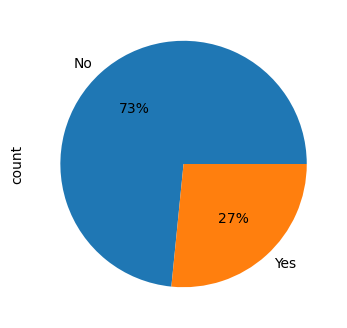

In [13]:
plt.figure(figsize=(8,4))
Y.value_counts().plot(kind='pie',autopct='%1.f%%',labels=['No','Yes'])
plt.show()

We have 2 classes, class 0 and class 1. **class 0 - minority class** and **class 1 - majority class** 

#### Fixing Imbalance using SMOTEENN

In [14]:
# Distribution of both classes in training data before applying smote technique.
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [15]:
# Applying SMOTE-ENN 

smote = SMOTEENN(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

# Class distribution after applying SMOTE - ENN
y_train_res.value_counts()

Churn
1    2554
0    2128
Name: count, dtype: int64

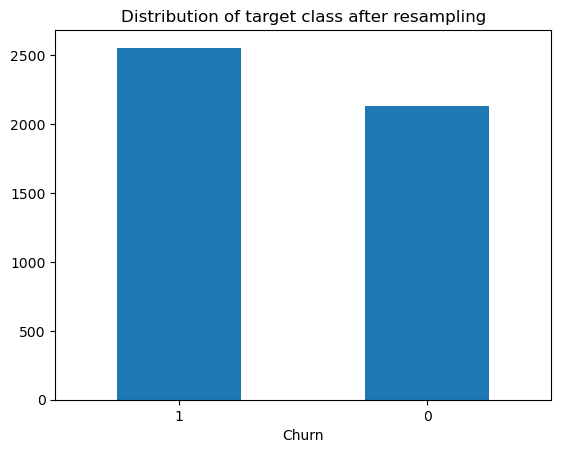

In [16]:
y_train_res.value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Distribution of target class after resampling')
plt.show()

Hence, now our data is divided into x_train_res,y_train_res,x_test,y_test

In [17]:
x_train_res.shape,y_train_res.shape,x_test.shape,y_test.shape

((4682, 50), (4682,), (1407, 50), (1407,))

#### Model Training

In this case, I am using top best 3 model to compare:
1. Decision Tree Classifier
2. Random Forest Classifiere
3. XGBoost Classifier
4. Gradient Boosting Classifierifier

#### 1. Decision Tree Classifier

In [28]:
model_dt_1 = DecisionTreeClassifier()
model_dt_1.fit(x_train_res,y_train_res)

DecisionTreeClassifier()

In [29]:
y_train

6021    1
3404    1
5474    1
5515    0
6328    0
       ..
3772    0
5191    0
5226    0
5390    0
860     1
Name: Churn, Length: 5625, dtype: int64

In [30]:
evaluating_model(model_dt_1,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2128
           1       1.00      1.00      1.00      2554

    accuracy                           1.00      4682
   macro avg       1.00      1.00      1.00      4682
weighted avg       1.00      1.00      1.00      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.86      0.76      0.80      1033
           1       0.49      0.66      0.57       374

    accuracy                           0.73      1407
   macro avg       0.68      0.71      0.68      1407
weighted avg       0.76      0.73      0.74      1407



The model performance is high on training data but very low on testing data. It is the problem of Overfitting.

Let's perform Hyperparameter tuning and GridSearch CV to improve the model performance.

#### Hyperparameter Tuning and GridSearch CV on Decision Tree

In [36]:
param_grid = {'criterion':['gini','entropy'],
             'max_depth':range(3,8),
             'max_leaf_nodes':range(3,12),
             'class_weight':['balanced']}

model_dt_2 = GridSearchCV(DecisionTreeClassifier(),param_grid=param_grid,cv=3,scoring='recall')
model_dt_2.fit(x_train_res,y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': ['balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': range(3, 8),
                         'max_leaf_nodes': range(3, 12)},
             scoring='recall')

In [37]:
model_dt_2.best_score_

0.9377428561445708

In [38]:
model_dt_2.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 3,
 'max_leaf_nodes': 7}

In [39]:
model_dt_2 = model_dt_2.best_estimator_

In [40]:
evaluating_model(model_dt_2,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2128
           1       0.89      0.95      0.92      2554

    accuracy                           0.91      4682
   macro avg       0.91      0.91      0.91      4682
weighted avg       0.91      0.91      0.91      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.89      0.67      0.77      1033
           1       0.46      0.78      0.58       374

    accuracy                           0.70      1407
   macro avg       0.68      0.72      0.67      1407
weighted avg       0.78      0.70      0.72      1407



Hence, performance of decision tree model is not satisfactory.

#### 2. Random Forest Classifier

In [63]:
model_rf_1 = RandomForestClassifier()
model_rf_1.fit(x_train_res,y_train_res)
evaluating_model(model_rf_1,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2128
           1       1.00      1.00      1.00      2554

    accuracy                           1.00      4682
   macro avg       1.00      1.00      1.00      4682
weighted avg       1.00      1.00      1.00      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.78      0.74      0.75      1407



#### Hyperparameter tuning on Random Forest Classifier

In [49]:
param_grid = {'n_estimators':[40,80,100,120,150,200],
              'criterion':['gini','entropy'],
              'max_depth':range(3,10)
             }

model_rf_2 = GridSearchCV(RandomForestClassifier(),param_grid=param_grid,cv=3,scoring='recall')
model_rf_2.fit(x_train_res,y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(3, 10),
                         'n_estimators': [40, 80, 100, 120, 150, 200]},
             scoring='recall')

In [50]:
model_rf_2.best_score_

0.9580917414658994

In [51]:
model_rf_2.best_params_

{'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 100}

In [52]:
model_rf_2 = model_rf_2.best_estimator_

In [53]:
evaluating_model(model_rf_2,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2128
           1       0.95      0.97      0.96      2554

    accuracy                           0.95      4682
   macro avg       0.95      0.95      0.95      4682
weighted avg       0.95      0.95      0.95      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



#### 3. XGBoost Classifier

In [61]:
model_xb_1 = XGBClassifier()
model_xb_1.fit(x_train_res,y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [62]:
evaluating_model(model_xb_1,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2128
           1       1.00      1.00      1.00      2554

    accuracy                           1.00      4682
   macro avg       1.00      1.00      1.00      4682
weighted avg       1.00      1.00      1.00      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.71      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



#### Hyperparameter tuning using RandomizedSearch CV on XGBoost Classifier

In [29]:
param_grid = {
    'n_estimators': [200,250,300],
    'max_depth': [3,4,5,6],
    'learning_rate': [0.01, 0.1,0.2],
    'gamma': [0, 0.1, 0.2],
    'subsample': [ 0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0]
}

In [91]:
model_xb = XGBClassifier(objective='binary:logistic',
            eval_metric='logloss')

random_Search = RandomizedSearchCV(model_xb,param_distributions=param_grid,n_iter=50,scoring='accuracy',cv=5,verbose=1,n_jobs=-1,random_state=42)
random_Search.fit(x_train_res,y_train_res)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [200, 250, 300],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [0.5, 1.0],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [92]:
random_Search.best_score_

0.9517470286146914

In [93]:
random_Search.best_params_

{'subsample': 1.0,
 'reg_lambda': 0.5,
 'reg_alpha': 0,
 'n_estimators': 250,
 'max_depth': 6,
 'learning_rate': 0.2,
 'gamma': 0,
 'colsample_bytree': 0.9}

In [94]:
model_xb_2 = random_Search.best_estimator_

In [95]:
evaluating_model(model_xb_2,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2128
           1       1.00      1.00      1.00      2554

    accuracy                           1.00      4682
   macro avg       1.00      1.00      1.00      4682
weighted avg       1.00      1.00      1.00      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1033
           1       0.51      0.69      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



#### 4. Gradient Boosting Classsifier

In [19]:
model_gb_1 = GradientBoostingClassifier(random_state=42)
model_gb_1.fit(x_train_res,y_train_res)

GradientBoostingClassifier(random_state=42)

In [20]:
evaluating_model(model_gb_1,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2128
           1       0.97      0.97      0.97      2554

    accuracy                           0.97      4682
   macro avg       0.97      0.96      0.96      4682
weighted avg       0.97      0.97      0.97      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



#### Hyperparameter Tuning using Randomized Search CV

In [43]:
param_grid = {
    'n_estimators':[150, 200, 250, 300],
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'loss': ['log_loss', 'exponential']
}

In [45]:
model_gb_2 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,  # Use param_distributions instead of param_grid
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_iter=20
)

model_gb_2.fit(x_train_res,y_train_res)

RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.001, 0.01, 0.1,
                                                          0.2],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': [2, 4, 6, 8],
                                        'n_estimators': [150, 200, 250, 300]},
                   random_state=42, scoring='accuracy')

In [46]:
model_gb_2.best_params_

{'n_estimators': 200,
 'max_depth': 6,
 'loss': 'exponential',
 'learning_rate': 0.01,
 'criterion': 'squared_error'}

In [47]:
model_gb_2=model_gb_2.best_estimator_

In [48]:
evaluating_model(model_gb_2,x_train_res,x_test)

Performance of the model on training data

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2128
           1       0.97      0.98      0.97      2554

    accuracy                           0.97      4682
   macro avg       0.97      0.97      0.97      4682
weighted avg       0.97      0.97      0.97      4682



Performance of the model on testing data

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



So far, the top 2 models are **Random Forest (with tuning)** and **Gradient Boosting (with tuning)**

To consider: (first case: RF, second case: GB)

1. **Accuracy:** In the first case, accuracy is 73%, and in the second case, it's 75%. Higher accuracy generally indicates better performance, but it's                  not the only metric to consider.

2. **Precision:** Precision measures the proportion of true positive predictions among all positive predictions. In the first case, precision is 50%,                     and in the second case, it's 52%. Higher precision means fewer false positives.

3. **Recall:** Recall measures the proportion of true positives that were correctly identified. In the first case, recall is 79%, and in the second                    case, it's 75%. Higher recall means fewer false negatives.

4. **F1 Score:** F1 Score is the harmonic mean of precision and recall. In the first case, it's 61%, and in the second case, it's also 62%. F1 Score                     provides a balance between precision and recall.n the two.

**Tips:** Given these metrics:

- If your priority is to minimize false positives (i.e.,you want to be very sure that the positive predictions are indeed correct), you might choose      the model with higher precision (the second one).
- If your priority is to minimize false negatives (i.e., you want to ensure that as many true positives as possible are identified), you might choose     the model with higher recall (the first one).
- If you want a balance between precision and recall, you might consider the F1 Score, in which case both models almost perform similarly.
- If the classes are balanced, you can consider accuracy as a reliable metric (in which second one is good).

#### Final Model Selection

After comparing multiple models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost), I decided to choose **Random Forest** as the final model for the following reasons:

- **Better Recall**:  
  In churn prediction problems, **Recall is more important than Accuracy** because we want to correctly identify as many churned customers as possible. Random Forest gave better recall compared to Gradient Boosting.

- **Balanced Performance**:  
  While Gradient Boosting achieved slightly higher accuracy, Random Forest provided a more balanced trade-off between **accuracy, recall, and precision**.

- **Avoiding Overfitting**:  
  Models like XGBoost showed signs of overfitting (perfect scores on training data but much lower performance on testing data). Random Forest generalized better on unseen data.

- **Interpretability & Stability**:  
  Random Forest is relatively easier to interpret (via feature importance) and provides stable results across different dat#a splits.

### ✅ Final Decision:
I will proceed with **Random Forest** as the final model for customer churn prediction because it offers **higher recall, good accuracy, and better generalization**, which is crucial in business scenarios where missing churners is costlier than false alarms.
